In [ ]:
%matplotlib ipympl

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal, norm

from kc import (
    Beta,
    Const,
    Flip,
    IfThenElse,
    Let,
    Observe,
    ObserveReal,
    Var,
    dsl,
    settings,
)
from kc import (
    TruncatableGaussian as _Gaussian,
)
from kc.inference import get_spn, kc, preprocess, run_kc
from kc.observation_weights import ObservationWeights
from kc.spn import WeightNode


---Settings---
{
  "union_of_sums": true,
  "debug": false,
  "transform_measures": true,
  "profiling": false
}
--------------


# Program Execution

In [4]:
with dsl.Model() as m:
    f1 = dsl.flip(0.5, name="f1")
    f2 = dsl.flip(0.1, name="f2")
    f3 = dsl.flip(0.8, name="f3")
    not_f3 = dsl.ifthenelse(f3, dsl.const(False), dsl.const(True))
    x = dsl.ifthenelse(f1, f2, not_f3)
    dsl.observe(x)

expr = m.compile("f1")

In [5]:
expr = Let(
    "f1",
    Flip(0.5),
    Let(
        "f2",
        Flip(0.1),
        Let(
            "f3",
            Flip(0.8),
            Let(
                "x",
                IfThenElse(
                    Var("f1"),
                    Var("f2"),
                    IfThenElse(
                        Var("f3"),
                        Const(False),
                        Const(True),
                    ),
                ),
                Let("_", Observe(Var("x")), Var("f1")),
            ),
        ),
    ),
)

In [ ]:
settings.debug = True
preprocess_state = preprocess(expr)
val, state = kc(expr, preprocess_state)
settings.debug = False

# BDD representation

In [7]:
from typing import Mapping

import dd.autoref as _bdd
import networkx as nx


def is_negated(u: _bdd.Function) -> bool:
    return u.node < 0  # type: ignore


def _build_graph(
    bdd: _bdd.BDD,
    u: _bdd.Function | _bdd._Ref,
    graph: nx.DiGraph,
    weights: Mapping[int, tuple[ObservationWeights, ObservationWeights]],
    visited: set,
    edge_labels: dict,
):
    if u in visited:
        return

    if u.low is None or u.high is None:
        return
    if is_negated(u):
        low, high = (~u.low, ~u.high)
    else:
        low, high = (u.low, u.high)

    node = u.var or u
    if node not in graph:
        graph.add_node(node)
    low_node = low.var or low.to_expr()
    if low_node not in graph:
        graph.add_node(low_node)
    high_node = high.var or high.to_expr()
    if high_node not in graph:
        graph.add_node(high_node)

    low_weight, high_weight = weights[u.var]  # type:ignore
    graph.add_edge(node, low_node, label=str(low_weight), weight=WeightNode(low_weight))
    graph.add_edge(
        node, high_node, label=str(high_weight), weight=WeightNode(high_weight)
    )
    edge_labels[node, low_node] = low_weight
    edge_labels[node, high_node] = high_weight
    visited.add(u)

    _build_graph(bdd, low, graph, weights, visited, edge_labels)
    _build_graph(bdd, high, graph, weights, visited, edge_labels)

    return


def build_graph(
    bdd: _bdd.BDD,
    u: _bdd.Function,
    weights: Mapping[
        int,
        tuple[ObservationWeights, ObservationWeights],
    ],
):
    graph = nx.DiGraph()
    edge_labels = {}
    _build_graph(bdd, u, graph, weights, set(), edge_labels)

    for layer, nodes in enumerate(nx.topological_generations(graph)):
        # `multipartite_layout` expects the layer as a node attribute, so add the
        # numeric layer value as a node attribute
        for node in nodes:
            graph.nodes[node]["layer"] = layer
    return graph, edge_labels


def plot_observes_bdd(state, node_label_map=None, edge_label_map=None):
    graph, edge_labels = build_graph(state.bdd, state.observes_all_hold, state.weights)
    if edge_label_map:
        for edge in edge_labels:
            edge_labels[edge] = edge_label_map(edge, edge_labels[edge])

    # Compute the multipartite_layout using the "layer" node attribute
    pos = nx.multipartite_layout(graph, subset_key="layer", align="horizontal")
    pos = {node: (x, -y) for (node, (x, y)) in pos.items()}

    if node_label_map:
        node_labels = {n: node_label_map(n) for n in graph}
    else:
        node_labels = None

    fig, ax = plt.subplots()
    nx.draw(graph, pos=pos, ax=ax, node_size=1200, node_color="skyblue")
    nx.draw_networkx_labels(graph, pos, labels=node_labels)
    _ = nx.draw_networkx_edge_labels(
        graph, pos=pos, edge_labels=edge_labels, ax=ax, label_pos=0.3, rotate=False
    )
    fig.tight_layout()
    ax.margins(x=0.2, y=0.2)

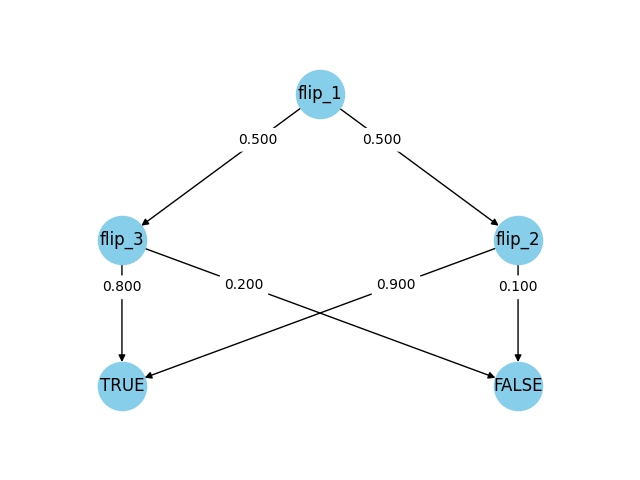

In [8]:
plot_observes_bdd(state)

# Weighted Model Counting

In [9]:
def get_post_order_internal_nodes(G, node=0):
    """Returns nodes in the order they should be evaluated."""
    res = []
    children = list(G.successors(node))
    for child in children:
        res.extend(get_post_order_internal_nodes(G, child))
    if len(children) > 0:  # We only need to evaluate internal nodes
        res.append(node)
    return res

def weighted_model_count_animation(state):
    G, edge_labels = build_graph(state.bdd, state.observes_all_hold, state.weights)
    pos = nx.multipartite_layout(G, subset_key="layer", align="horizontal")
    pos = {node: (x, -y) for (node, (x, y)) in pos.items()}
    eval_order = get_post_order_internal_nodes(G, node=state.observes_all_hold.var)
    for node in G:
        G.nodes[node]["weight"] = 0.
    G.nodes["TRUE"]["weight"] = WeightNode(ObservationWeights(1.0))
    G.nodes["FALSE"]["weight"] = WeightNode(ObservationWeights(0.0))


    # Pre-calculate animation frames to avoid mutating state during the animation loop
    frames = []
    current_weights = {n: G.nodes[n]['weight'] for n in G.nodes()}

    frames.append({'type': 'init', 'weights': current_weights.copy()})

    for node in eval_order:
        l_child, r_child = list(G.successors(node))
        l_edge_w = G[node][l_child]['weight']
        r_edge_w = G[node][r_child]['weight']
        
        # Calculate the traveling values
        l_term = l_edge_w * current_weights[l_child]
        r_term = r_edge_w * current_weights[r_child]
        
        # Frame sequence for this node
        frames.append({'type': 'highlight', 'node': node, 'weights': current_weights.copy()})
        
        for t in np.linspace(0, 1, 15): # 15 frames for the travel animation
            frames.append({
                'type': 'move', 'node': node, 'l_child': l_child, 'r_child': r_child,
                'l_val': l_term, 'r_val': r_term, 't': t, 'weights': current_weights.copy()
            })
            
        current_weights[node] = l_term + r_term
        frames.append({'type': 'update', 'node': node, 'weights': current_weights.copy()})
        
        # Add a brief pause (duplicate frames) before moving to the next node
        for _ in range(5):
            frames.append({'type': 'update', 'node': node, 'weights': current_weights.copy()})

    # 4. Drawing and Animation Setup
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Weighted Model Counting", fontsize=14, fontweight='bold')

    # Draw static background graph
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=15, edge_color='gray')
    edge_labels = {(u, v): f"x {G[u][v]['weight'].weight}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', ax=ax, label_pos=0.7, rotate=False)

    # Draw updatable node elements
    node_collection = nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightblue', node_size=800)
    node_labels = {n: str(w) for n, w in current_weights.items()}
    texts = nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax, font_size=12, font_weight='bold')

    # Initialize traveling markers and text (invisible to start)
    marker_l, = ax.plot([np.nan], [np.nan], 'o', color='orange', markersize=25, zorder=5)
    marker_r, = ax.plot([np.nan], [np.nan], 'o', color='orange', markersize=25, zorder=5)
    text_l = ax.text(0, 0, '', color='black', fontsize=10, fontweight='bold', ha='center', va='center', zorder=6)
    text_r = ax.text(0, 0, '', color='black', fontsize=10, fontweight='bold', ha='center', va='center', zorder=6)

    def update(frame_data):
        """Update function for FuncAnimation."""
        # Reset node text to current frame state
        for n, w in frame_data['weights'].items():
            if isinstance(w, WeightNode):
                texts[n].set_text(str(w.weight))
            else:
                texts[n].set_text(str(w))
            
        colors = ['lightblue'] * len(G.nodes)
        marker_l.set_data([np.nan], [np.nan])
        marker_r.set_data([np.nan], [np.nan])
        text_l.set_text('')
        text_r.set_text('')
        
        if frame_data['type'] in ['highlight', 'move']:
            idx = list(G.nodes).index(frame_data['node'])
            colors[idx] = '#FFD700' # Highlight node Yellow
            
            if frame_data['type'] == 'move':
                # Interpolate position along the edge based on 't'
                t = frame_data['t']
                p0_l, p1_l = np.array(pos[frame_data['l_child']]), np.array(pos[frame_data['node']])
                p0_r, p1_r = np.array(pos[frame_data['r_child']]), np.array(pos[frame_data['node']])
                
                curr_l = p0_l + t * (p1_l - p0_l)
                curr_r = p0_r + t * (p1_r - p0_r)
                
                # Update moving visual elements
                marker_l.set_data([curr_l[0]], [curr_l[1]])
                text_l.set_position((curr_l[0], curr_l[1]))
                text_l.set_text(str(frame_data['l_val'].weight))
                
                marker_r.set_data([curr_r[0]], [curr_r[1]])
                text_r.set_position((curr_r[0], curr_r[1]))
                text_r.set_text(str(frame_data['r_val'].weight))
                
        elif frame_data['type'] == 'update':
            idx = list(G.nodes).index(frame_data['node'])
            colors[idx] = '#90EE90' # Flash Light Green on successful update
            
        node_collection.set_facecolor(colors)
        
        # Return modified artists for blitting
        return [node_collection, marker_l, marker_r, text_l, text_r] + list(texts.values())

    return animation.FuncAnimation(fig, update, frames=frames, interval=150, blit=True, repeat=True)

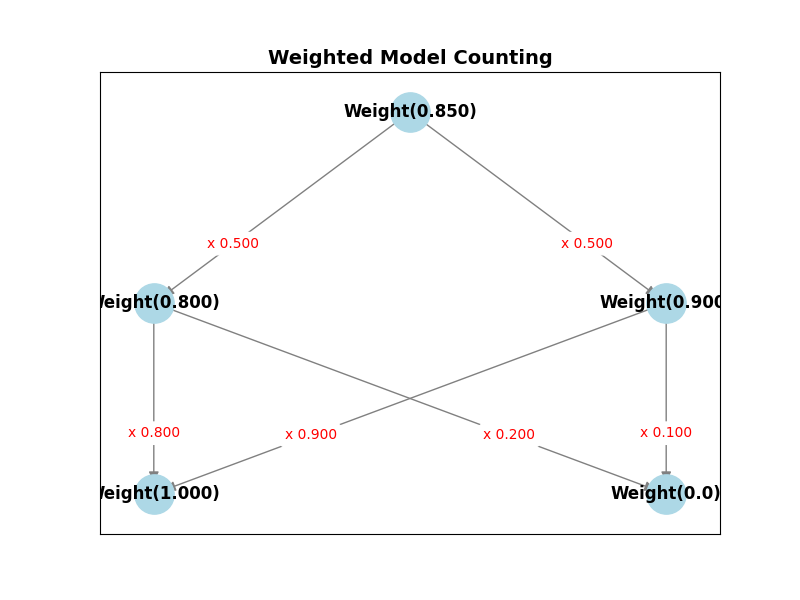

In [10]:
weighted_model_count_animation(state)

# Symbolic Gaussian Variables

In [11]:
expr = Let(
    "flip",
    Flip(0.5),
    Let(
        "g1",
        _Gaussian(0, 1),
        Let(
            "g2",
            _Gaussian(0, 2),
            Let(
                "x",
                IfThenElse(
                    Var("flip"),
                    Var("g1"),
                    Var("g2"),
                ),
                Let("_", ObserveReal(Var("x"), 1.0), Var("flip")),
            ),
        ),
    ),
)

with dsl.Model() as m:
    flip = dsl.flip(0.5, name="flip")
    g1 = dsl.gaussian(0, 1, name="g1")
    g2 = dsl.gaussian(0, 2, name="g2")
    x = dsl.ifthenelse(flip, g1, g2)
    dsl.observe(x, 1)

expr = m.compile("flip")

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/var/folders/rn/jqrwv4s94353h34h4r7t__sm0000gn/T/ipykernel_56216/1605721975.py:6: SyntaxWarning: invalid escape sequence '\e'
  edge_label_map=lambda e, weight: f"{weight}$\epsilon$"


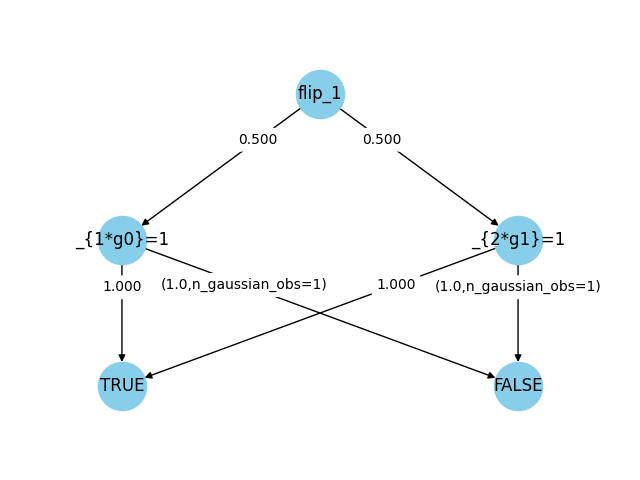

In [12]:
preprocess_state = preprocess(expr)
val, state = kc(expr, preprocess_state)
plot_observes_bdd(
    state,
    node_label_map=lambda n: str(n).split("|")[0],
    edge_label_map=lambda e, weight: f"{weight}$\epsilon$"
    if "g" in str(e[0]) and weight.likelihood != 1.
    else weight,
)

# Exact Conditioning

## 1D

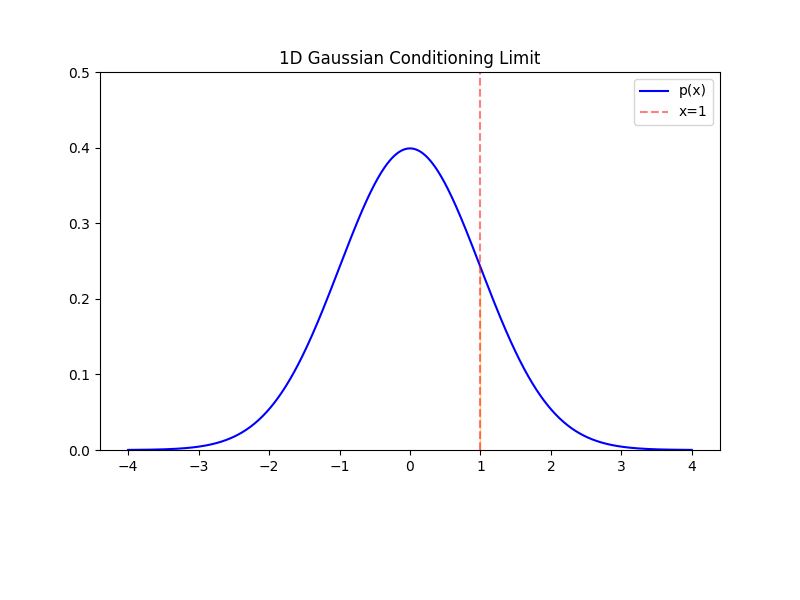

In [13]:
# --- Animation 1: 1D Gaussian ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
x_vals = np.linspace(-4, 4, 1000)
pdf_vals = norm.pdf(x_vals)
ax1.plot(x_vals, pdf_vals, label="p(x)", color="blue")
ax1.axvline(x=1, color="red", linestyle="--", alpha=0.5, label="x=1")

# Rectangle to represent the epsilon width
rect = plt.Rectangle((1, 0), 0, norm.pdf(1), color="orange", alpha=0.5)
ax1.add_patch(rect)

# Equation text area
eq_text = ax1.text(0.5, -0.3, "", transform=ax1.transAxes, ha="center", fontsize=12)
ax1.set_ylim(0, 0.5)
ax1.set_title("1D Gaussian Conditioning Limit")
ax1.legend()
plt.subplots_adjust(bottom=0.25)


def init1():
    rect.set_width(0)
    rect.set_xy((1, 0))
    eq_text.set_text("")
    return rect, eq_text


def update1(frame):
    # Epsilon shrinks from 2.0 to 0.05 over 50 frames
    eps = 2.0 - (1.95 * (frame / 50))
    rect.set_width(eps)
    rect.set_xy((1 - eps / 2, 0))

    # Calculate probability mass approximation
    area = norm.pdf(1) * eps

    # Equation update
    eq_string = (
        r"$\mathbb{E}[Y \mid X = x] = \lim_{\epsilon \to 0} \mathbb{E}[Y \mid x - \frac{\epsilon}{2} < X < x + \frac{\epsilon}{2}]$"
        + "\n"
        + r" $\triangleq p(x)\epsilon$"
    )
    eq_text.set_text(eq_string)
    return rect, eq_text


ani1 = animation.FuncAnimation(fig1, update1, frames=51, init_func=init1, blit=True)

## 2D

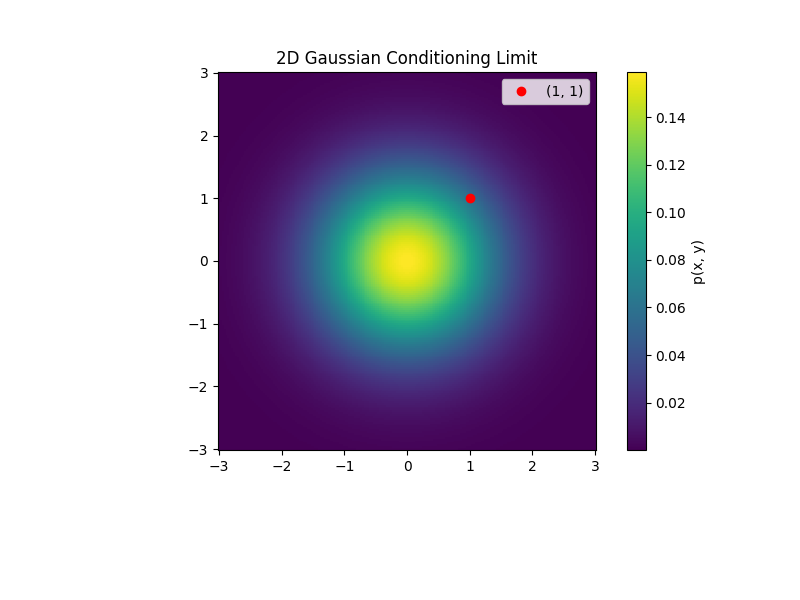

In [14]:
# --- Animation 2: 2D Gaussian ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
X, Y = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
pos = np.dstack((X, Y))
rv = multivariate_normal([0, 0], [[1, 0], [0, 1]])
Z = rv.pdf(pos)

c = ax2.pcolormesh(X, Y, Z, shading="auto", cmap="viridis")
fig2.colorbar(c, ax=ax2, label="p(x, y)")
ax2.plot(1, 1, "ro", label="(1, 1)")

# Square to represent the epsilon width
rect2 = plt.Rectangle((1, 1), 0, 0, color="red", fill=False, lw=2)
ax2.add_patch(rect2)

eq_text2 = ax2.text(0.5, -0.3, "", transform=ax2.transAxes, ha="center", fontsize=12)
ax2.set_title("2D Gaussian Conditioning Limit")
ax2.legend()
ax2.set_aspect("equal")
plt.subplots_adjust(bottom=0.25)


def init2():
    rect2.set_width(0)
    rect2.set_height(0)
    rect2.set_xy((1, 1))
    eq_text2.set_text("")
    return rect2, eq_text2


def update2(frame):
    eps = 2.0 - (1.95 * (frame / 50))
    rect2.set_width(eps)
    rect2.set_height(eps)
    rect2.set_xy((1 - eps / 2, 1 - eps / 2))

    vol = rv.pdf([1, 1]) * (eps**2)

    eq_string2 = (
        r"$\mathbb{E}[Z \mid X = 1, Y = 1] = \lim_{\epsilon \to 0} \mathbb{E}[Z \mid (X,Y) \in [1 -\frac{\epsilon}{2}, 1 + \frac{\epsilon}{2}]^2]$"
        + "\n"
        + r"$\triangleq p(x,y)\epsilon^2$"
    )
    eq_text2.set_text(eq_string2)
    return rect2, eq_text2


ani2 = animation.FuncAnimation(fig2, update2, frames=51, init_func=init2, blit=True)

## Tropical Semiring

$\mathbb{R}_{\min}[\epsilon] = \{a \epsilon^n \mid a \in \mathbb{R}, n\in \mathbb{N}\}$
- $\epsilon^n \otimes \epsilon^m = \epsilon^{n \cdot m}$
- $\epsilon^n \oplus \epsilon^m = \epsilon^{\min(n, m)}$


# Beta Latents

In [15]:
expr = Let(
    "b",
    Beta(3, 1),
    Let(
        "f1",
        Flip(Var("b")),
        Let(
            "f2",
            Flip(Var("b")),
            Let(
                "f3",
                Flip(Var("b")),
                Let(
                    "x",
                    IfThenElse(
                        Var("f1"),
                        Var("f2"),
                        IfThenElse(
                            Var("f3"),
                            Const(False),
                            Const(True),
                        ),
                    ),
                    Let("_", Observe(Var("x")), Var("b")),
                ),
            ),
        ),
    ),
)

with dsl.Model() as m:
    b = dsl.beta(3, 1, name="b")
    f1 = dsl.flip(b)
    f2 = dsl.flip(b)
    f3 = dsl.flip(0.8)
    x = dsl.ifthenelse(f1, f2, dsl.ifthenelse(f3, dsl.const(False), dsl.const(True)))
    dsl.observe(x)

expr = m.compile("b")

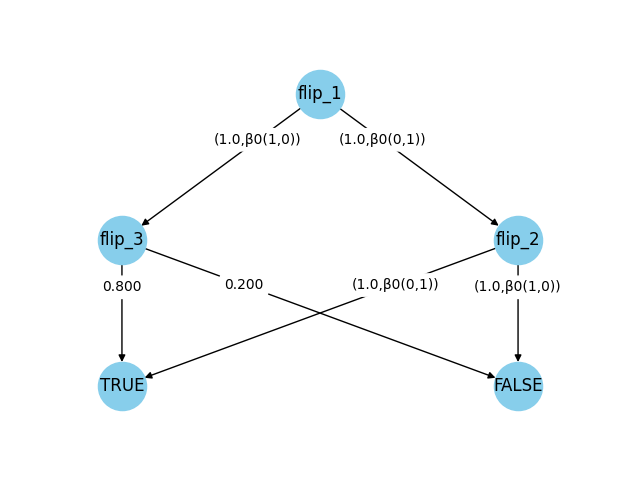

In [16]:
preprocess_state = preprocess(expr)
val, state = kc(expr, preprocess_state)
plot_observes_bdd(
    state,
)

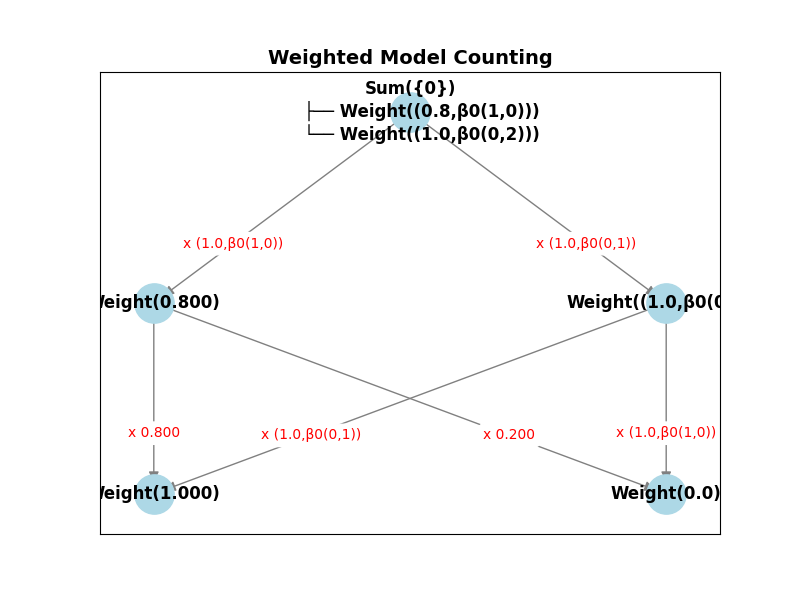

In [17]:
weighted_model_count_animation(state)

# Sum Product Networks

In [18]:
with dsl.Model() as m:
    b1 = dsl.beta(3, 1, name="b1")
    b2 = dsl.beta(1, 2, name="b2")
    b3 = dsl.beta(1, 1, name="b3")
    f1 = dsl.flip(b1)
    f2 = dsl.flip(b1)
    f3 = dsl.flip(b2)
    f4 = dsl.flip(b3)
    x = dsl.ifthenelse(f1, f2, dsl.ifthenelse(f3, dsl.const(False), dsl.const(True)))
    y = dsl.ifthenelse(f2, f3, f1)
    z = dsl.ifthenelse(f4, x, y)
    dsl.observe(z)

expr = m.compile("b1")
spn = get_spn(expr)

print(spn)

Sum({0, 1, 2})
    ├── Product({0, 1, 2})
    │   ├── Sum({1, 2})
    │   │   ├── Weight((1.0,β1(1,0)))
    │   │   └── Weight(Obs(likelihood=1.000, scope={1, 2}, n_beta_obs=2))
    │   └── Weight((1.0,β0(2,0)))
    ├── Weight(Obs(likelihood=1.000, scope={0, 2}, n_beta_obs=2))
    ├── Product({0, 1, 2})
    │   ├── Sum({1, 2})
    │   │   ├── Weight(Obs(likelihood=1.000, scope={1, 2}, n_beta_obs=2))
    │   │   └── Weight(Obs(likelihood=1.000, scope={1, 2}, n_beta_obs=2))
    │   └── Weight((1.0,β0(1,1)))
    └── Weight(Obs(likelihood=1.000, scope={0, 1, 2}, n_beta_obs=3))


`Weight(w, p)`
Posterior $p$ with mixture weight $w$

`Sum((w_1, p_1), ..., (w_n, p_n))`
Mixture distribution $p(x) = \sum w_i p_i(x)$

`Product(p_1, ..., p_n)`
Distribution $p(x)$ that factors as product of independent distributions $p(x) = \prod p_i(x_i)$



`Sum` - Shared scope

`Product` - Disjoint scopes

# Gaussian Latents

In [ ]:
with dsl.Model() as m:
    x = dsl.gaussian(0.0, 1.0, name="x")
    y = dsl.gaussian(0.0, 1.0, name="y")
    z = x + y
    dsl.observe(z, 1.0)

### **Prior Distributions**

* **Marginal Density of $X$:**

$$X \sim \mathcal{N}(0, 1)$$


* **Marginal Density of $Y$:**

$$Y \sim \mathcal{N}(0, 1)$$


* **Joint Density of $(X, Y)$:**

$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} 0 \\ 0 \end{bmatrix}, \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} \right)$$



---

### **Posterior Distributions**

* **Posterior Marginal of $X$:**

$$X \mid (X + Y = 1) \sim \mathcal{N}(0.5, 0.5)$$


* **Posterior Marginal of $Y$:**

$$Y \mid (X + Y = 1) \sim \mathcal{N}(0.5, 0.5)$$


* **Posterior Joint of $(X, Y)$:**

$$\begin{bmatrix} X \\ Y \end{bmatrix} \Big| (X + Y = 1) \sim \mathcal{N}\left( \begin{bmatrix} 0.5 \\ 0.5 \end{bmatrix}, \begin{bmatrix} 0.5 & -0.5 \\ -0.5 & 0.5 \end{bmatrix} \right)$$

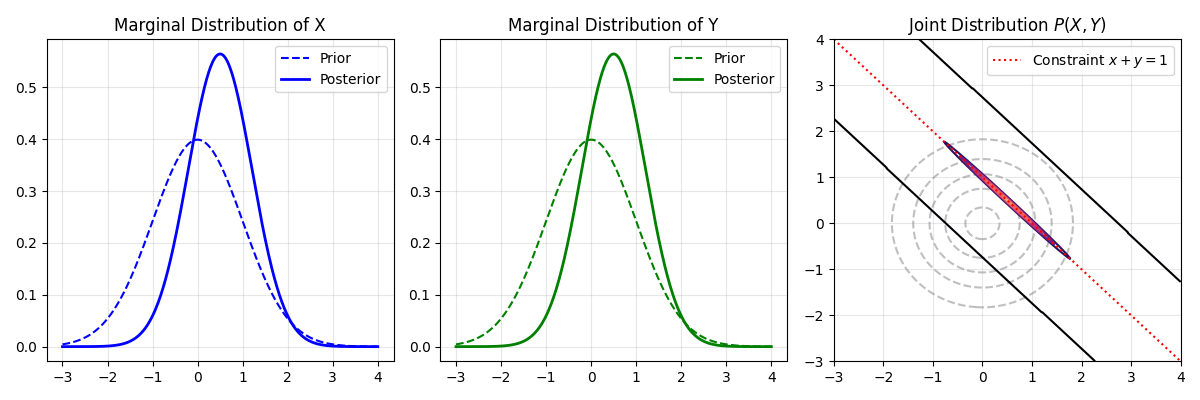

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# Setup for plots
x_range = np.linspace(-3, 4, 500)
y_range = np.linspace(-3, 4, 500)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
pos = np.dstack((X_grid, Y_grid))

# Prior and Posterior parameters
prior_mean, prior_var = 0, 1
post_mean, post_var = 0.5, 0.5

# Joint parameters (with epsilon for numerical stability in the degenerate case)
eps = 1e-3
post_mean_vec = [0.5, 0.5]
post_cov_mat = [[0.5 + eps, -0.5], [-0.5, 0.5 + eps]]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Marginal X (Prior vs Posterior)
axes[0].plot(x_range, norm.pdf(x_range, prior_mean, np.sqrt(prior_var)), 
             label='Prior', color='blue', linestyle='--')
axes[0].plot(x_range, norm.pdf(x_range, post_mean, np.sqrt(post_var)), 
             label='Posterior', color='blue', linewidth=2)
axes[0].set_title('Marginal Distribution of X')
axes[0].legend()

# Plot 2: Marginal Y (Prior vs Posterior)
axes[1].plot(y_range, norm.pdf(y_range, prior_mean, np.sqrt(prior_var)), 
             label='Prior', color='green', linestyle='--')
axes[1].plot(y_range, norm.pdf(y_range, post_mean, np.sqrt(post_var)), 
             label='Posterior', color='green', linewidth=2)
axes[1].set_title('Marginal Distribution of Y')
axes[1].legend()

# Plot 3: Joint (X, Y)
# Prior contours (gray dashed circles)
prior_rv = multivariate_normal([0, 0], [[1, 0], [0, 1]])
axes[2].contour(X_grid, Y_grid, prior_rv.pdf(pos), levels=5, colors='gray', alpha=0.5, linestyles='--')
# Posterior contours (magma ellipse along the line)
post_rv = multivariate_normal(post_mean_vec, post_cov_mat)
axes[2].contour(X_grid, Y_grid, post_rv.pdf(pos), levels=5, cmap='magma')
# Explicit constraint line
axes[2].plot(x_range, 1 - x_range, color='red', linestyle=':', label='Constraint $x+y=1$')

axes[2].set_title('Joint Distribution $P(X, Y)$')
axes[2].set_xlim([-3, 4]); axes[2].set_ylim([-3, 4])
axes[2].legend()

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
x_posterior, Z = run_kc(m.compile("x"))
y_posterior, Z = run_kc(m.compile("y"))

print("X posterior")
print("\n".join([f"{i}: {p}" for i, p in enumerate(x_posterior)]))
print("-------")

print("Y posterior")
print("\n".join([f"{i}: {p}" for i, p in enumerate(y_posterior)]))

X posterior
0: FullPosterior(likelihood= 100.000%, n_obs=1, GaussianPosterior(mu=[0.5], cov=[0.5]))
-------
Y posterior
0: FullPosterior(likelihood= 100.000%, n_obs=1, GaussianPosterior(mu=[0.5], cov=[0.5]))


In [21]:
with dsl.Model() as m:
    x = dsl.gaussian(0.0, 1.0, name="x")
    y = dsl.gaussian(0.0, 1.0, name="y")
    z = dsl.ifthenelse(dsl.flip(0.5), x + y, y)

    dsl.observe(z, 1.0)

x_posterior, Z = run_kc(m.compile("x"))
y_posterior, Z = run_kc(m.compile("y"))

print("X posterior")
print("\n".join([f"{i}: {p}" for i, p in enumerate(x_posterior)]))
print("-------")

print("Y posterior")
print("\n".join([f"{i}: {p}" for i, p in enumerate(y_posterior)]))

X posterior
0: FullPosterior(likelihood= 47.588%, n_obs=1, GaussianPosterior(mu=[0.5], cov=[0.5]))
1: FullPosterior(likelihood= 52.412%, n_obs=1)
-------
Y posterior
0: FullPosterior(likelihood= 47.588%, n_obs=1, GaussianPosterior(mu=[0.5], cov=[0.5]))
1: FullPosterior(likelihood= 52.412%, n_obs=1, GaussianPosterior(mu=[1.], cov=[0.]))
